<a href="https://colab.research.google.com/github/Jenny5789/python/blob/main/%EC%9A%B0%EB%A6%AC%EB%82%98%EB%9D%BC%EB%8C%80%EA%B8%B0%EC%98%A4%EC%97%BC_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# ====== 1. 초기 설정 ======
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# 나눔고딕 폰트 설치 (코랩 한글 깨짐 방지)
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

# matplotlib에 폰트 직접 등록
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
mpl.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 음수 기호 깨짐 방지
print("✅ 설정 완료!")

✅ 설정 완료!


In [25]:
# ====== 2. 데이터 불러오기 ======
# 에어코리아에서 다운받은 2025년 5월 대기오염 데이터
df = pd.read_excel("airkorea.xlsx", skiprows=5, header=None)

# 컬럼명 수동 지정 (원본 파일에 헤더가 깔끔하지 않아서)
df.columns = ["번호", "시도", "SO2(ppm)", "NO2(ppm)", "O3(ppm)", "CO(ppm)",
              "PM10_월평균", "PM10_황사제외", "PM25_월평균", "PM25_황사제외"]

# 빈 행 및 불필요한 컬럼 제거
df = df.dropna(subset=["시도"]).drop(columns=["번호"]).reset_index(drop=True)

In [26]:
# ====== 3. 데이터 정리 ======
# 전국 평균 따로 저장
national = df[df["시도"] == "전국"]["PM25_월평균"].values[0]

# 시도별 데이터만 추출 (전국 제외)
cities = df[df["시도"] != "전국"].copy()

# 전국 평균 대비 차이 계산
cities["PM25_차이"] = cities["PM25_월평균"] - national

# 파일 하단 주석 행 제거 (숫자 데이터가 아닌 행 필터링)
cities = cities[cities["PM25_월평균"].apply(lambda x: str(x).replace('.','').isdigit())]
cities = cities.reset_index(drop=True)


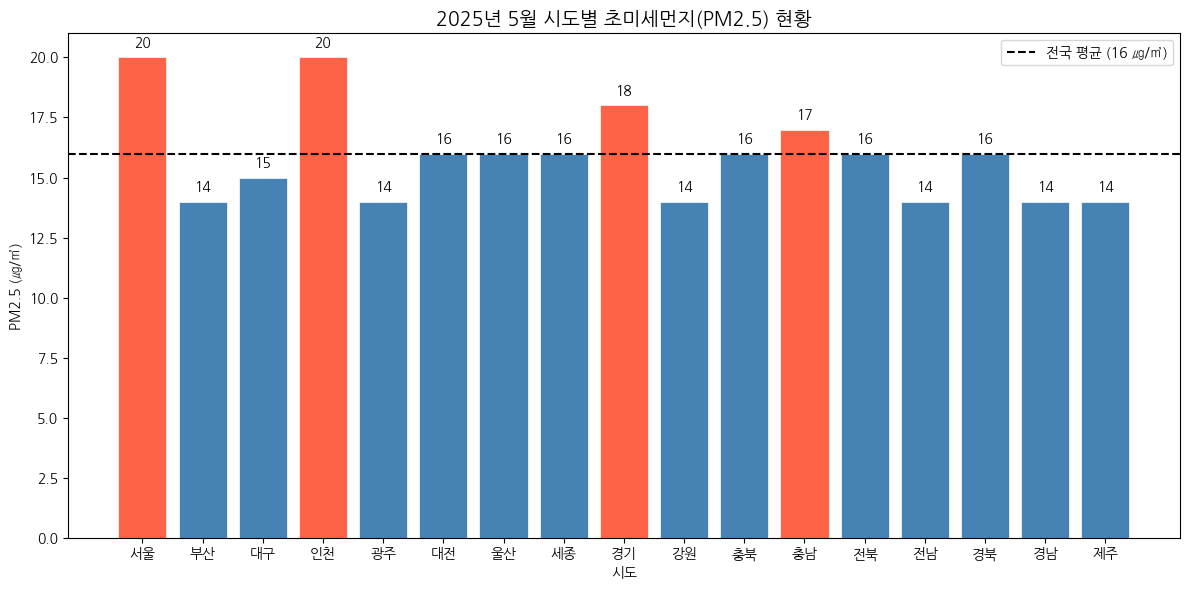

In [27]:
# ====== 4. 시각화 ======
fig, ax = plt.subplots(figsize=(12, 6))

# 전국 평균보다 높으면 빨강, 낮으면 파랑
colors = ["tomato" if x > 0 else "steelblue" for x in cities["PM25_차이"]]
bars = ax.bar(cities["시도"], cities["PM25_월평균"], color=colors, edgecolor="white", linewidth=0.5)

# 전국 평균 기준선
ax.axhline(y=national, color="black", linestyle="--", linewidth=1.5, label=f"전국 평균 ({national} ㎍/㎥)")

# 막대 위에 수치 표시
for bar, val in zip(bars, cities["PM25_월평균"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha="center", va="bottom", fontsize=10)

ax.set_title("2025년 5월 시도별 초미세먼지(PM2.5) 현황", fontsize=14, fontweight="bold")
ax.set_ylabel("PM2.5 (㎍/㎥)")
ax.set_xlabel("시도")
ax.legend()
plt.tight_layout()
plt.show()